In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

#imported ALL libraries in this cell even the ones used in the last cells
# to avoid import errors in the pytest tests


In [3]:
df = pd.read_csv('E:/OneDrive/Documents/coding/MLInternship/week2/Titanic-Dataset.csv')

In [4]:
df = df.drop(['ivPassengerId', 'Ticket'], axis = 1)

In [5]:
print (df.isnull().sum())

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64


In [6]:
df['Age'].fillna(df['Age'].median(), inplace=True)


C:\Users\mabdu\AppData\Local\Temp\ipykernel_30592\286566303.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [7]:
print (df.columns)

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Cabin', 'Embarked'],
      dtype='object')


In [ ]:
df = df.drop('Cabin', axis=1)

In [ ]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [ ]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [ ]:
#Reload the original data to get the 'Cabin' column
df_cabin = pd.read_csv('E:/OneDrive/Documents/coding/MLInternship/week2/Titanic-Dataset.csv')

#Add the 'Cabin' column back to your main DataFrame
df['Cabin'] = df_cabin['Cabin']

In [ ]:
df['cabin_deck'] = df['Cabin'].fillna('U').astype(str).str[0]


In [ ]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin,cabin_deck
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,NaN,U
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,NaN,U
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,C123,C
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,NaN,U


In [19]:
#df = df.drop('Cabin', axis=1)

In [22]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,cabin_deck
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,U
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,U
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,C
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,U


In [23]:
# Survival Analysis by Cabin Presence and Deck
# Survival rate for passengers who had a cabin vs those who did not
survivedbycabin = df.groupby('hascabin')['Survived'].mean()
print("Survival rate by cabin presence (0 = No Cabin, 1 = Has Cabin):")
print(survivedbycabin)


# Survival rate for each cabin deck
if 'cabin_deck' in df.columns:
    survivedbydeck = df.groupby('cabin_deck')['Survived'].mean().sort_index()
    print("\nSurvival rate by cabin deck:")
    print(survivedbydeck)
else:
    print("Column 'cabin_deck' not found in DataFrame.")

    #pandas profiling

KeyError: 'hascabin'

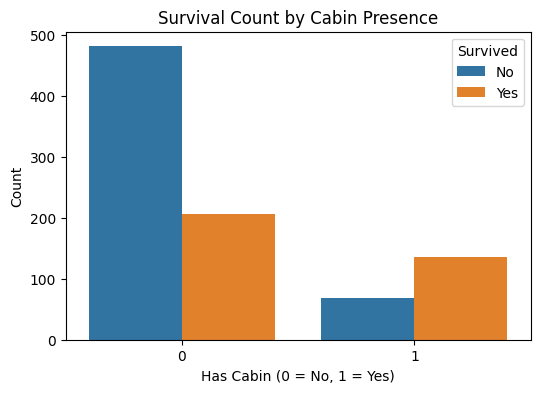

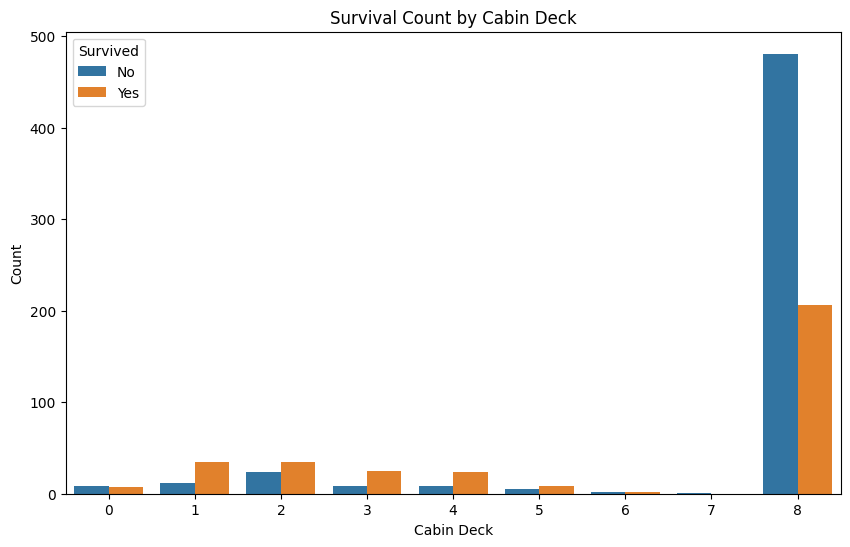

In [ ]:
# Histogram for survival by cabin presence
plt.figure(figsize=(6,4))
sns.countplot(x='hascabin', hue='Survived', data=df)
plt.title('Survival Count by Cabin Presence')
plt.xlabel('Has Cabin (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

# Histogram for survival by cabin deck (if available)
plt.figure(figsize=(10,6))
sns.countplot(x='cabin_deck', hue='Survived', data=df, order=sorted(df['cabin_deck'].unique()))
plt.title('Survival Count by Cabin Deck')
plt.xlabel('Cabin Deck')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()


In [ ]:
df.head(10)

,Survived,Pclass,Sex,Age,Fare,hascabin,FamilySize,cabin_deck
0,0,3,1,22.0,7.2500,0,2,8
1,1,1,0,38.0,71.2833,1,2,2
2,1,3,0,26.0,7.9250,0,1,8
3,1,1,0,35.0,53.1000,1,2,2
4,0,3,1,35.0,8.0500,0,1,8
5,0,3,1,28.0,8.4583,0,1,8
6,0,1,1,54.0,51.8625,1,1,4
7,0,3,1,2.0,21.0750,0,5,8
8,1,3,0,27.0,11.1333,0,3,8
9,1,2,0,14.0,30.0708,0,2,8


In [ ]:
#failed attempt on encoding 
df.drop(columns=[col for col in df.columns if col.startswith('cabin_deck_') or col == 'Sex_male'], inplace=True)
df.drop(columns=[col for col in df.columns if col.startswith('deck_')], inplace=True)
df.drop(columns=['embarked_code'], inplace=True)

#joblib dump


KeyError: "['embarked_code'] not found in axis"

In [ ]:
original_df = pd.read_csv('E:/OneDrive/Documents/coding/MLInternship/week2/Titanic-Dataset.csv')
# Restore 'Sex' and 'Cabin' columns from original file
df['Sex'] = original_df['Sex']
df['Cabin'] = original_df['Cabin']



In [ ]:
df['cabin_deck'] = df['Cabin'].fillna('U').astype(str).str[0]


In [ ]:
df = df.drop('Cabin', axis=1)

In [ ]:
df = df.drop('Embarked', axis=1)

In [ ]:
df = df.drop(['SibSp', 'Parch'], axis=1)

In [ ]:
df.head(10)

,Survived,Pclass,Sex,Age,Fare,hascabin,FamilySize,IsAlone,FamilyType,cabin_deck
0,0,3,male,22.0,7.2500,0,2,0,Small,U
1,1,1,female,38.0,71.2833,1,2,0,Small,C
2,1,3,female,26.0,7.9250,0,1,1,Alone,U
3,1,1,female,35.0,53.1000,1,2,0,Small,C
4,0,3,male,35.0,8.0500,0,1,1,Alone,U
5,0,3,male,28.0,8.4583,0,1,1,Alone,U
6,0,1,male,54.0,51.8625,1,1,1,Alone,E
7,0,3,male,2.0,21.0750,0,5,0,Large,U
8,1,3,female,27.0,11.1333,0,3,0,Small,U
9,1,2,female,14.0,30.0708,0,2,0,Small,U


In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

def family_type(size):
    if size == 1:
        return 'Alone'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

df['FamilyType'] = df['FamilySize'].apply(family_type)



"\ndf['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves\ndf['IsAlone'] = (df['FamilySize'] == 1).astype(int)\n\ndef family_type(size):\n    if size == 1:\n        return 'Alone'\n    elif size <= 4:\n        return 'Small'\n    else:\n        return 'Large'\n\ndf['FamilyType'] = df['FamilySize'].apply(family_type)\n"

In [ ]:
df.groupby('FamilySize')['Survived'].mean()
df.groupby('IsAlone')['Survived'].mean()

#almost 51% chance of survival if with family
#less then 31%  chance of survival if alone

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

In [ ]:
df.head(10)

,Survived,Pclass,Sex,Age,Fare,hascabin,FamilySize,IsAlone,FamilyType,cabin_deck
0,0,3,male,22.0,7.2500,0,2,0,Small,U
1,1,1,female,38.0,71.2833,1,2,0,Small,C
2,1,3,female,26.0,7.9250,0,1,1,Alone,U
3,1,1,female,35.0,53.1000,1,2,0,Small,C
4,0,3,male,35.0,8.0500,0,1,1,Alone,U
5,0,3,male,28.0,8.4583,0,1,1,Alone,U
6,0,1,male,54.0,51.8625,1,1,1,Alone,E
7,0,3,male,2.0,21.0750,0,5,0,Large,U
8,1,3,female,27.0,11.1333,0,3,0,Small,U
9,1,2,female,14.0,30.0708,0,2,0,Small,U


In [ ]:
'''
encode sex male = 1 female = 0
encode familytype alone = 1 small = 2 large = 3
encode cabin_deck somehow  

'''

In [ ]:
#encode Sex: male = 1 female = 0
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

#ncode FamilyType: Alone = 1 Small = 2 Large = 3 
family_type_mapping = {'Alone': 1, 'Small': 2, 'Large': 3}
df['FamilyType'] = df['FamilyType'].map(family_type_mapping)

#encode cabin_deck using LabelEncoder
#fill missing with 'U' before encoding
df['cabin_deck'] = df['cabin_deck'].fillna('U')

deck_encoder = LabelEncoder()
df['cabin_deck'] = deck_encoder.fit_transform(df['cabin_deck'])

In [ ]:
df.head(20)

,Survived,Pclass,Sex,Age,Fare,hascabin,FamilySize,IsAlone,FamilyType,cabin_deck
0,0,3,1,22.0,7.2500,0,2,0,2,8
1,1,1,0,38.0,71.2833,1,2,0,2,2
2,1,3,0,26.0,7.9250,0,1,1,1,8
3,1,1,0,35.0,53.1000,1,2,0,2,2
4,0,3,1,35.0,8.0500,0,1,1,1,8
5,0,3,1,28.0,8.4583,0,1,1,1,8
6,0,1,1,54.0,51.8625,1,1,1,1,4
7,0,3,1,2.0,21.0750,0,5,0,3,8
8,1,3,0,27.0,11.1333,0,3,0,2,8
9,1,2,0,14.0,30.0708,0,2,0,2,8


In [ ]:
df = df.drop(['IsAlone'], axis =1)

In [ ]:
df = df.drop(['FamilyType'],axis =1)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,Fare,hascabin,FamilySize,cabin_deck
0,0,3,1,22.0,7.2500,0,2,8
1,1,1,0,38.0,71.2833,1,2,2
2,1,3,0,26.0,7.9250,0,1,8
3,1,1,0,35.0,53.1000,1,2,2
4,0,3,1,35.0,8.0500,0,1,8


In [ ]:
df.drop('Fare',axis =1)

,Survived,Pclass,Sex,Age,hascabin,FamilySize,cabin_deck
0,0,3,1,22.0,0,2,8
1,1,1,0,38.0,1,2,2
2,1,3,0,26.0,0,1,8
3,1,1,0,35.0,1,2,2
4,0,3,1,35.0,0,1,8
...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,1,8
887,1,1,0,19.0,1,1,1
888,0,3,0,28.0,0,4,8
889,1,1,1,26.0,1,1,2


In [ ]:
x = df.drop(['Survived', 'Fare'], axis =1)
y = df['Survived']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)



ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'

In [ ]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=2))
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [ ]:
#used this to determine the K value



'''
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    pipeline = Pipeline([
        ('scalar', StandardScaler()),
        ('clf', knn)
    ])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"K={k}: Test Accuracy = {score:.4f}")

best_k = k_range[scores.index(max(scores))]
print(f"Best K: {best_k} with accuracy {max(scores):.4f}")

'''

'\nfrom sklearn.neighbors import KNeighborsClassifier\nfrom sklearn.model_selection import cross_val_score\n\nk_range = range(1, 21)\nscores = []\n\nfor k in k_range:\n    knn = KNeighborsClassifier(n_neighbors=k)\n    pipeline = Pipeline([\n        (\'scalar\', StandardScaler()),\n        (\'clf\', knn)\n    ])\n    pipeline.fit(X_train, y_train)\n    score = pipeline.score(X_test, y_test)\n    scores.append(score)\n    print(f"K={k}: Test Accuracy = {score:.4f}")\n\nbest_k = k_range[scores.index(max(scores))]\nprint(f"Best K: {best_k} with accuracy {max(scores):.4f}")\n\n'

In [ ]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.8441
DecisionTree testing accuracy: 0.8101
------------------------------
KNN training accuracy: 0.8680
KNN testing accuracy: 0.8045
------------------------------
Naive-Bayes training accuracy: 0.7865
Naive-Bayes testing accuracy: 0.7933
------------------------------


In [ ]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} prediction accuracy on test set: {acc:.4f}")

DecisionTree prediction accuracy on test set: 0.8101
KNN prediction accuracy on test set: 0.8045
Naive-Bayes prediction accuracy on test set: 0.7933


--- DecisionTree ---
              precision    recall  f1-score   support

           0     0.8087    0.8857    0.8455       105
           1     0.8125    0.7027    0.7536        74

    accuracy                         0.8101       179
   macro avg     0.8106    0.7942    0.7995       179
weighted avg     0.8103    0.8101    0.8075       179

Confusion Matrix for DecisionTree:


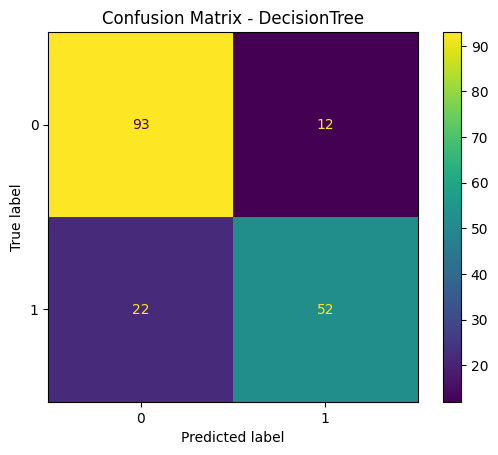

----------------------------------------
--- KNN ---
              precision    recall  f1-score   support

           0     0.7966    0.8952    0.8430       105
           1     0.8197    0.6757    0.7407        74

    accuracy                         0.8045       179
   macro avg     0.8081    0.7855    0.7919       179
weighted avg     0.8061    0.8045    0.8008       179

Confusion Matrix for KNN:


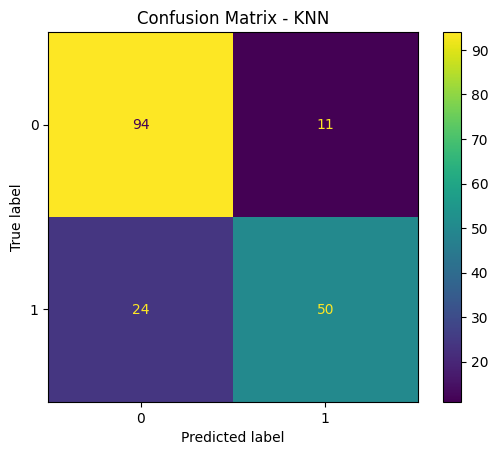

----------------------------------------
--- Naive-Bayes ---
              precision    recall  f1-score   support

           0     0.8617    0.7714    0.8141       105
           1     0.7176    0.8243    0.7673        74

    accuracy                         0.7933       179
   macro avg     0.7897    0.7979    0.7907       179
weighted avg     0.8021    0.7933    0.7947       179

Confusion Matrix for Naive-Bayes:


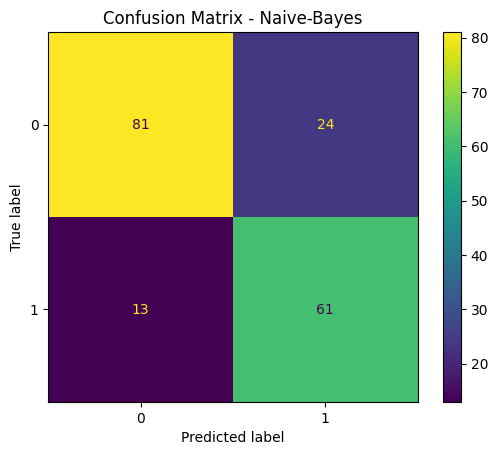

----------------------------------------


In [ ]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, digits=4))
    print(f"Confusion Matrix for {name}:")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    print("-" * 40)